<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/main_press.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANDO BIBLIOTECAS

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

# DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# WINDOW

In [ ]:
def window(N, wt):

    nn = N - 1
    pn = 2 * np.pi * np.arange(0, nn + 1) / nn

    if wt[:4] == 'rect':
        w = np.ones(N)

    elif wt[:4] == 'tria':
        m = nn // 2
        w = np.arange(0, m + 1) / m
        w = np.concatenate([w, w[::-1][1:]])

    elif wt[:4] == 'hann':
        w = 0.5 * (1 - np.cos(pn))

    elif wt[:4] == 'hamm':
        w = 0.54 - 0.46 * np.cos(pn)

    elif wt[:4] == 'blac':
        w = (
            0.42
            - 0.5 * np.cos(pn)
            + 0.08 * np.cos(2 * pn)
        )

    else:
        raise ValueError('Tipo de janela inválido')

    return w

# WEIN

In [ ]:
def weim(N, wt, x):

    w = window(N, wt)

    x = np.array(x).flatten()

    ln = (N - 1) // 2
    lx = len(x)
    lf = lx - ln

    y = np.zeros_like(x)

    for i in range(lx):

        # início
        if i < ln:

            y[i] = (
                np.sum(x[:ln+i+1] * w[ln-i:])
                / np.sum(w[ln-i:])
            )

        # centro
        elif i >= ln and i < lf:

            y[i] = (
                np.sum(x[i-ln:i+ln+1] * w)
                / np.sum(w)
            )

        # final
        else:

            y[i] = (
                np.sum(x[i-ln:] * w[:len(x[i-ln:])])
                / np.sum(w[:len(x[i-ln:])])
            )

    return y

# FUNC DE PROCESSAMENTO

In [ ]:
def processar_press(caminho_pasta, nome_saida):

    # procura arquivos txt
    arquivos = sorted(glob(os.path.join(caminho_pasta, '*.txt')))

    lista_df = []

    for arq in arquivos:

        nome_arquivo = os.path.basename(arq)

        # ==========================================
        # EXTRAIR DATA DO NOME DO ARQUIVO
        # ==========================================

        data_str = nome_arquivo.replace('Press', '').replace('.txt', '')

        data_inicial = pd.to_datetime(
            data_str,
            format='%Y%m%d%H%M%S%f'
        )

        # ==========================================
        # LEITURA DOS DADOS
        # ==========================================

        dados = pd.read_csv(
            arq,
            skiprows=2,
            header=None,
            names=['altura_cm'],
            dtype=str
        )

        # remover espaços
        dados['altura_cm'] = dados['altura_cm'].str.strip()

        # converter para número
        dados['altura_cm'] = pd.to_numeric(
            dados['altura_cm'],
            errors='coerce'
        )

        # remover linhas inválidas
        dados = dados.dropna(subset=['altura_cm'])

        # ==========================================
        # CONVERTER PARA METROS
        # ==========================================

        dados['altura_m'] = (
            dados['altura_cm'].astype(float) / 100
        )

        # ==========================================
        # REMOVER MARÉ
        # ==========================================

        mare = weim(
            275,
            'blac',
            dados['altura_m'].values
        )

        dados['altura_h'] = (
            dados['altura_m'] - mare
        )

        # ==========================================
        # GERAR TEMPO
        # 2 Hz = 0.5 s
        # ==========================================

        tempo = pd.date_range(
            start=data_inicial,
            periods=len(dados),
            freq='500ms'
        )

        dados['DataHora'] = tempo

        # manter apenas colunas finais
        dados = dados[['DataHora', 'altura_h']]

        lista_df.append(dados)

    # ==========================================
    # CONCATENAR
    # ==========================================

    df_final = pd.concat(
        lista_df,
        ignore_index=True
    )

    # ordenar
    df_final = df_final.sort_values('DataHora')

    # reset índice
    df_final = df_final.reset_index(drop=True)

    # ==========================================
    # CORTES TEMPORAIS
    # ==========================================

    if nome_saida == 'Press_CHU':

        inicio = pd.to_datetime(
            '2025-03-27 13:20:00'
        )

        fim = pd.to_datetime(
            '2025-04-02 16:00:00'
        )

        df_final = df_final[
            (df_final['DataHora'] >= inicio) &
            (df_final['DataHora'] <= fim)
        ]

    if nome_saida == 'Press_SEC':

        inicio = pd.to_datetime(
            '2025-11-22 18:00:00'
        )

        fim = pd.to_datetime(
            '2025-11-30 09:00:00'
        )

        df_final = df_final[
            (df_final['DataHora'] >= inicio) &
            (df_final['DataHora'] <= fim)
        ]

    # reset índice
    df_final = df_final.reset_index(drop=True)

    # ==========================================
    # SALVAR CSV
    # ==========================================

    caminho_saida = (
        f'/content/drive/MyDrive/Ondas/Dados/Refinados/{nome_saida}.csv'
    )

    df_final.to_csv(
        caminho_saida,
        index=False,
        date_format='%Y-%m-%d %H:%M:%S.%f'
    )

    return df_final

# CHUVOSO


In [ ]:
caminho_chu = '/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/Press'

Press_CHU = processar_press(
    caminho_chu,
    'Press_CHU'
)

# PROCESSAMENTO SECO

In [ ]:
caminho_sec = '/content/drive/MyDrive/Ondas/Dados/novembro2025/SCO2/Press'

Press_SEC = processar_press(
    caminho_sec,
    'Press_SEC'
)

# FIGURA

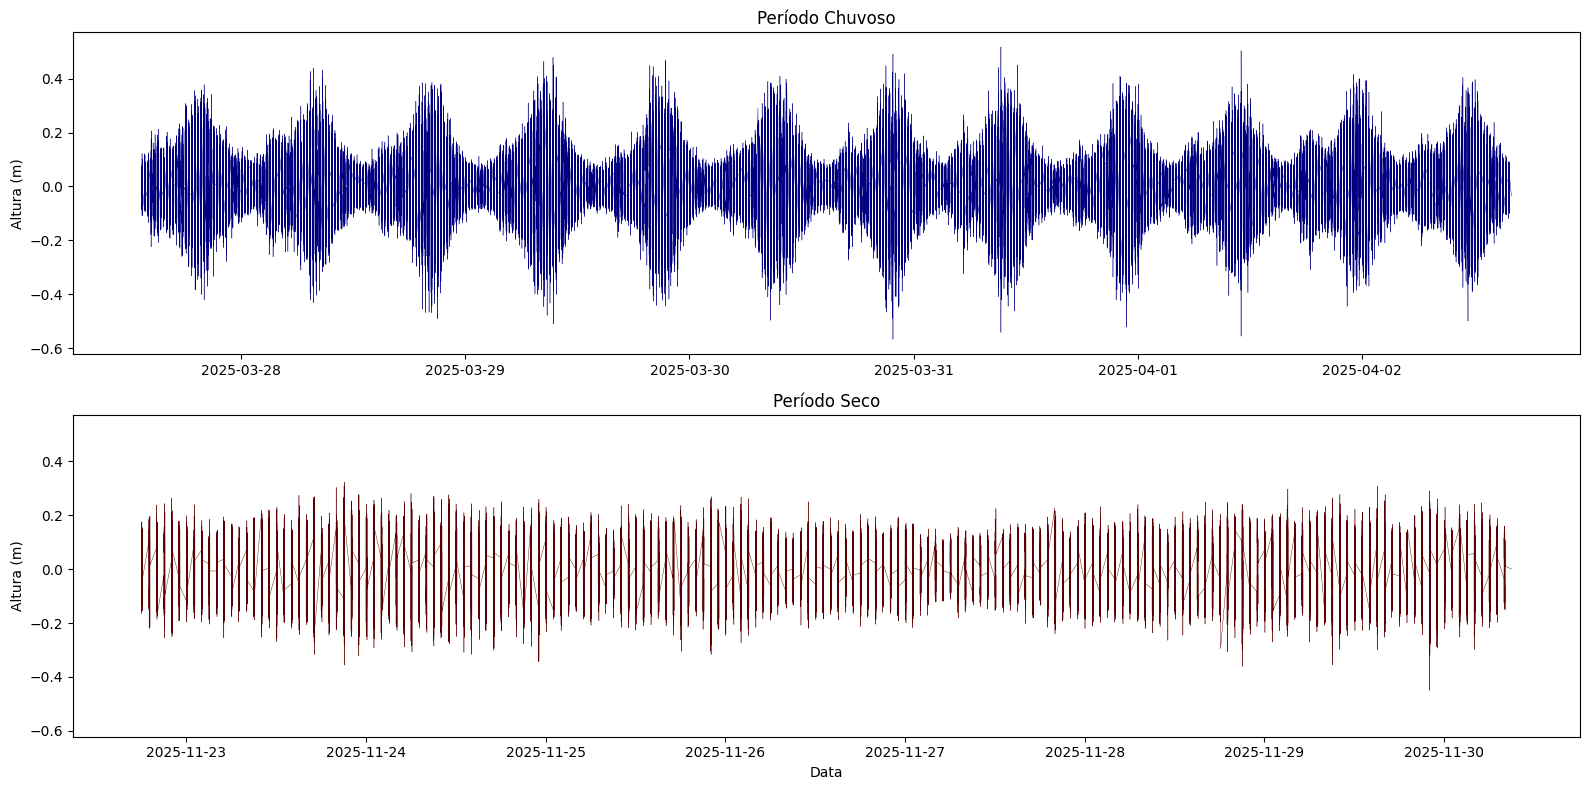

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# CHUVOSO
ax[0].plot(
    Press_CHU['DataHora'],
    Press_CHU['altura_h'],
    color='navy',
    linewidth=0.3
)

ax[0].set_title('Período Chuvoso')
ax[0].set_ylabel('Altura (m)')

# SECO
ax[1].plot(
    Press_SEC['DataHora'],
    Press_SEC['altura_h'],
    color='#5A0000',   # vermelho escuro/vinho
    linewidth=0.3
)

ax[1].set_title('Período Menos Chuvoso')
ax[1].set_ylabel('Altura (m)')
ax[1].set_xlabel('Data')

# AJUSTES
plt.tight_layout()

plt.show()

# DF Individuais

In [ ]:
df_press_chu = Press_CHU.copy()
df_press_sec = Press_SEC.copy()

# garantir datetime
df_press_chu['DataHora'] = pd.to_datetime(df_press_chu['DataHora'])
df_press_sec['DataHora'] = pd.to_datetime(df_press_sec['DataHora'])

## Func para identificar ondas (zero ascendente)

In [ ]:
def individual_waves(serie):

    serie = np.array(serie)

    # cruzamentos ascendentes
    cruz = np.where(
        (serie[:-1] < 0) &
        (serie[1:] >= 0)
    )[0]

    alturas = []

    # calcular altura de cada onda
    for i in range(len(cruz)-1):

        trecho = serie[cruz[i]:cruz[i+1]]

        if len(trecho) > 0:

            H = np.max(trecho) - np.min(trecho)

            alturas.append(H)

    return np.array(alturas)

## Func Hs
média de  1/3 maior

In [ ]:
def calc_hs_series(serie):

    alturas = individual_waves(serie)

    if len(alturas) == 0:
        return np.nan

    # ordenar decrescente
    alturas = np.sort(alturas)[::-1]

    # 1/3 maior
    n = int(len(alturas) / 3)

    if n == 0:
        return np.nan

    hs = np.mean(alturas[:n])

    return hs


# Hs Geral

In [ ]:
HsChu = calc_hs_series(
    df_press_chu['altura_h']
)

HsSec = calc_hs_series(
    df_press_sec['altura_h']
)

print(f'Hs Chuvoso = {HsChu:.3f} m')
print(f'Hs Seco = {HsSec:.3f} m')

Hs Chuvoso = 0.248 m
Hs Seco = 0.247 m


# Hs em janelas

In [ ]:
def calc_hs_intervalo(df, intervalo):

    resultados = []

    # resample temporal
    grupos = df.resample(
        intervalo,
        on='DataHora'
    )

    for tempo, grupo in grupos:

        if len(grupo) > 10:

            hs = calc_hs_series(
                grupo['altura_h']
            )

            resultados.append([tempo, hs])

    # dataframe final
    df_hs = pd.DataFrame(
        resultados,
        columns=['DataHora', 'Hs']
    )

    return df_hs

# Hs 10 min

In [ ]:
df_Hs_10min_CHU = calc_hs_intervalo(
    df_press_chu,
    '10min'
)

df_Hs_10min_SEC = calc_hs_intervalo(
    df_press_sec,
    '10min'
)

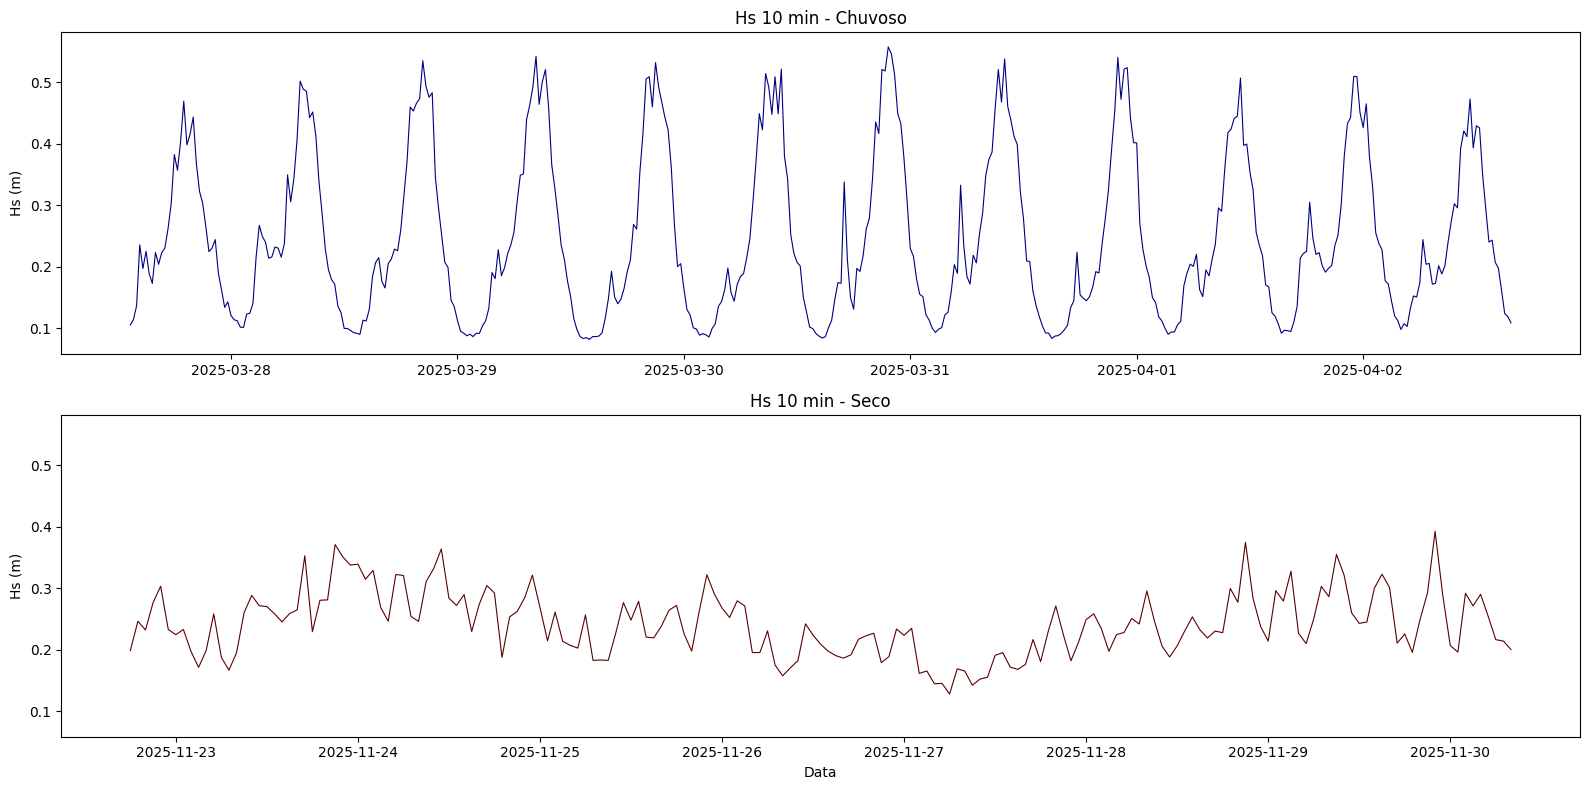

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso
ax[0].plot(
    df_Hs_10min_CHU['DataHora'],
    df_Hs_10min_CHU['Hs'],
    color='navy',
    linewidth=0.8
)

ax[0].set_title('Hs 10 min - Chuvoso')
ax[0].set_ylabel('Hs (m)')

# seco
ax[1].plot(
    df_Hs_10min_SEC['DataHora'],
    df_Hs_10min_SEC['Hs'],
    color='#5A0000',
    linewidth=0.8
)

ax[1].set_title('Hs 10 min - Seco')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

# Hs 1H

In [ ]:
df_Hs_1H_CHU = calc_hs_intervalo(
    df_press_chu,
    '1H'
)

df_Hs_1H_SEC = calc_hs_intervalo(
    df_press_sec,
    '1H'
)

/tmp/ipykernel_19789/102215150.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


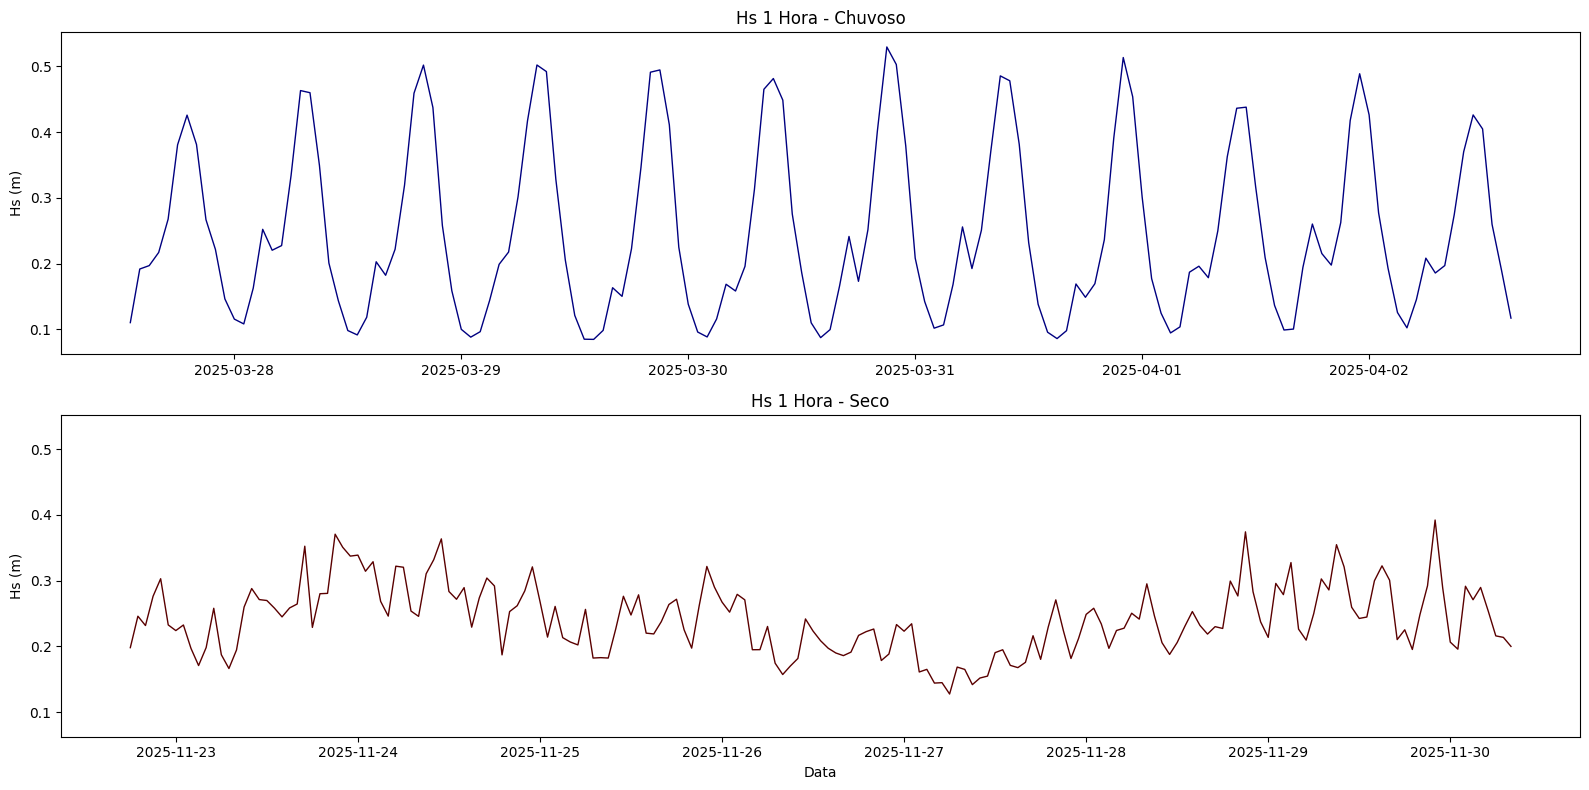

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso
ax[0].plot(
    df_Hs_1H_CHU['DataHora'],
    df_Hs_1H_CHU['Hs'],
    color='navy',
    linewidth=1
)

ax[0].set_title('Hs 1 Hora - Chuvoso')
ax[0].set_ylabel('Hs (m)')

# seco
ax[1].plot(
    df_Hs_1H_SEC['DataHora'],
    df_Hs_1H_SEC['Hs'],
    color='#5A0000',
    linewidth=1
)

ax[1].set_title('Hs 1 Hora - Seco')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

# Hs 3H

In [ ]:
df_Hs_3H_CHU = calc_hs_intervalo(
    df_press_chu,
    '3H'
)

df_Hs_3H_SEC = calc_hs_intervalo(
    df_press_sec,
    '3H'
)

/tmp/ipykernel_19789/102215150.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(
/tmp/ipykernel_19789/102215150.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


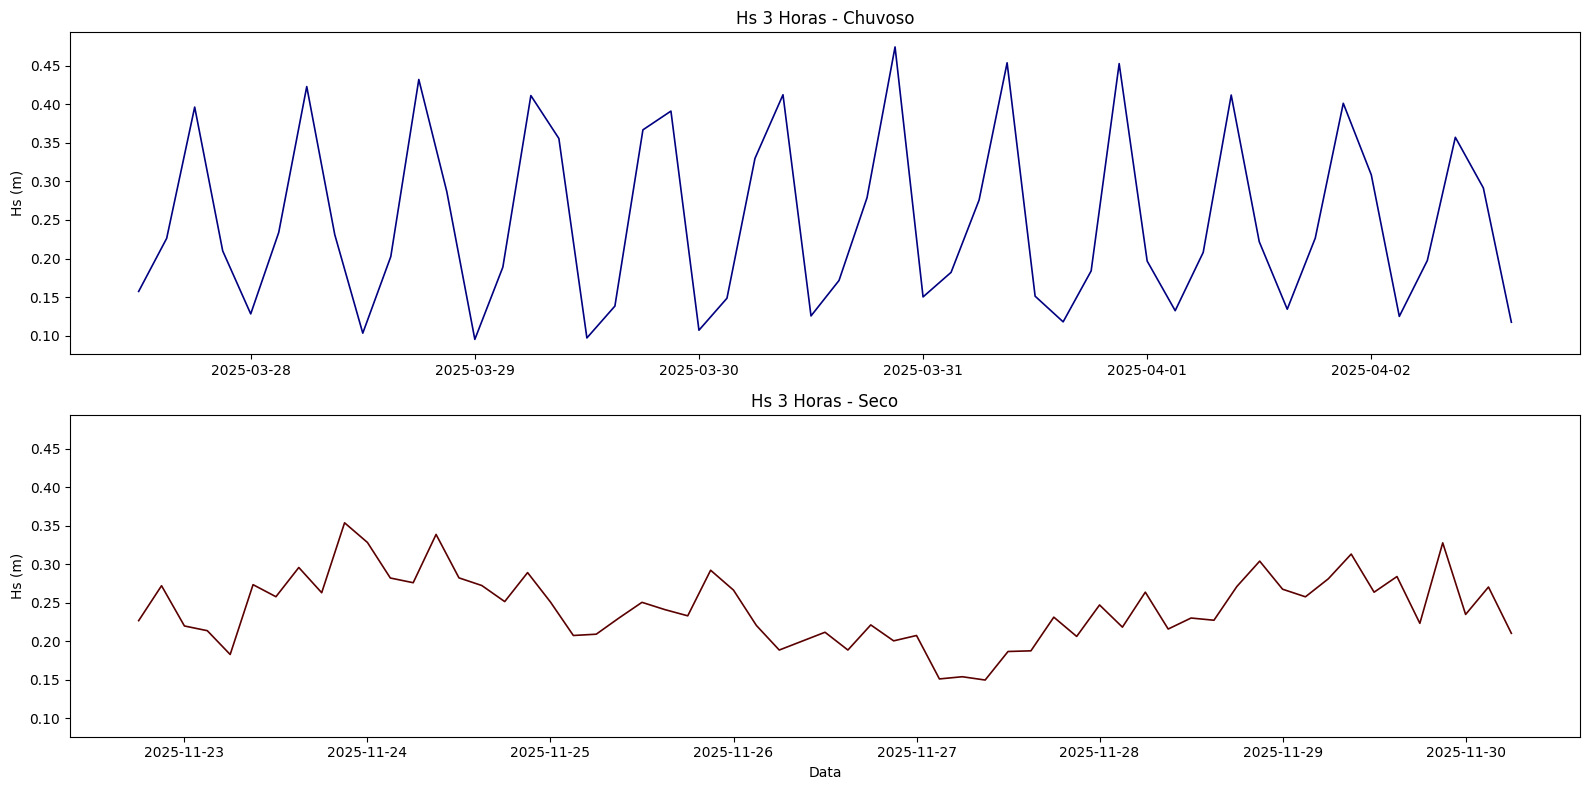

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso
ax[0].plot(
    df_Hs_3H_CHU['DataHora'],
    df_Hs_3H_CHU['Hs'],
    color='navy',
    linewidth=1.2
)

ax[0].set_title('Hs 3 Horas - Chuvoso')
ax[0].set_ylabel('Hs (m)')

# seco
ax[1].plot(
    df_Hs_3H_SEC['DataHora'],
    df_Hs_3H_SEC['Hs'],
    color='#5A0000',
    linewidth=1.2
)

ax[1].set_title('Hs 3 Horas - Seco')
ax[1].set_ylabel('Hs (m)')
ax[1].set_xlabel('Data')

plt.tight_layout()
plt.show()